In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

import datetime as dt

# import required libraries for clustering
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

![](https://static.vecteezy.com/system/resources/previews/010/925/820/non_2x/colorful-welcome-design-template-free-vector.jpg)

![](https://media.geeksforgeeks.org/wp-content/uploads/clusteringg.jpg)

**Clustering in Machine Learning: Unraveling Patterns in Data 🌐🔍**

**Definition:** Clustering is a type of unsupervised learning where the goal is to group similar data points into clusters or segments based on their intrinsic patterns, without prior knowledge of class labels.

**Objective:** 🎯 The primary aim of clustering is to uncover the hidden structures or relationships within a dataset. It helps in understanding the natural groupings or associations that might exist among the data points.

**Algorithms:**

1. **K-Means:** 🤖 Divides data into 'k' clusters by minimizing the sum of squared distances between data points and their assigned cluster centroids.

2. **Hierarchical Clustering:** 🌳 Builds a tree-like hierarchy of clusters by iteratively merging or splitting them based on similarity.

3. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** 📊 Identifies clusters as dense regions separated by sparser areas, handling irregularly shaped clusters.

4. **Agglomerative Clustering:** 🤝 Starts with individual data points and merges them into clusters until a stopping criterion is met.

5. **Gaussian Mixture Models (GMM):** 🌈 Models data as a mixture of Gaussian distributions, allowing for flexible cluster shapes and accommodating different variances.

**Applications:**

1. **Customer Segmentation:** 🛒 Identifying groups of customers with similar behavior or preferences for targeted marketing.

2. **Image Segmentation:** 📸 Partitioning an image into meaningful segments based on pixel similarity.

3. **Anomaly Detection:** 🕵️ Identifying unusual patterns or outliers that do not conform to the majority of the data.

4. **Document Clustering:** 📚 Grouping similar documents together for tasks like topic modeling or recommendation systems.

5. **Genomic Clustering:** 🧬 Identifying patterns in gene expression data for understanding biological relationships.

**Evaluation:**

1. **Internal Measures (e.g., Silhouette Score):** Assessing the cohesion and separation within clusters.

2. **External Measures (e.g., Adjusted Rand Index):** Evaluating the clustering results against known ground truth.

3. **Visual Inspection:** Examining visualizations, such as cluster plots or dendrograms, to understand the structure.

**Challenges:**

1. **Choosing the Right Number of Clusters (k):** Selecting an appropriate value for k is often subjective and depends on the nature of the data.

2. **Sensitivity to Initial Conditions:** K-Means, in particular, is sensitive to the initial placement of cluster centroids.

3. **Handling Noise and Outliers:** Some algorithms struggle with noise, and the presence of outliers can impact cluster assignments.

**Conclusion:** Clustering is a powerful tool for pattern recognition and exploration in unlabeled datasets, contributing valuable insights to diverse fields within machine learning and data analysis.

**import the data**

In [3]:
df=pd.read_csv('/content/drive/MyDrive/Lab 5 - Clustering/CC GENERAL.csv')

**check shape of the data**

In [ ]:
df.shape

(8950, 18)

In [ ]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [ ]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

**We can drop the missing values as it has very few items**

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isna().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

![](https://almablog-media.s3.ap-south-1.amazonaws.com/image02_81f0f88c38.png)

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'BALANCE'),
  Text(1, 0, 'BALANCE_FREQUENCY'),
  Text(2, 0, 'PURCHASES'),
  Text(3, 0, 'ONEOFF_PURCHASES'),
  Text(4, 0, 'INSTALLMENTS_PURCHASES')])

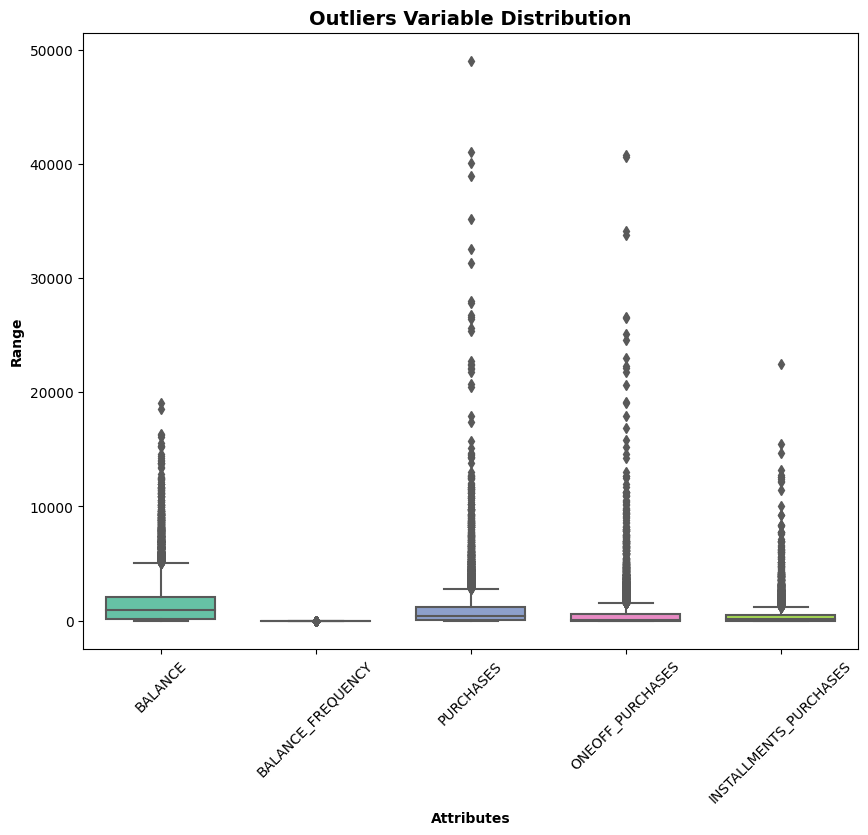

In [ ]:
# Outlier Analysis
import math
num_attributes = [x for x in df.columns if df[x].dtype in ('float64','int64')]
num_attributes_1 = num_attributes[:math.floor((len(num_attributes))/3)]
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = df[num_attributes_1], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'CASH_ADVANCE'),
  Text(1, 0, 'PURCHASES_FREQUENCY'),
  Text(2, 0, 'ONEOFF_PURCHASES_FREQUENCY'),
  Text(3, 0, 'PURCHASES_INSTALLMENTS_FREQUENCY'),
  Text(4, 0, 'CASH_ADVANCE_FREQUENCY'),
  Text(5, 0, 'CASH_ADVANCE_TRX'),
  Text(6, 0, 'PURCHASES_TRX'),
  Text(7, 0, 'CREDIT_LIMIT')])

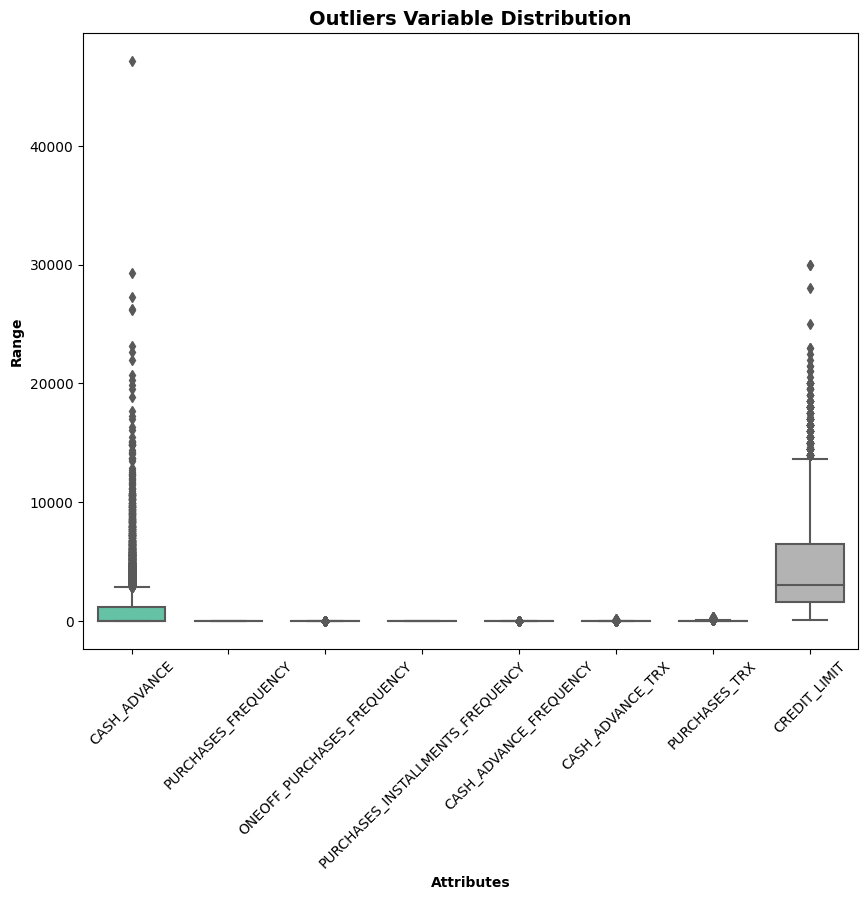

In [ ]:


num_attributes_2 = num_attributes[math.floor((len(num_attributes))/3):len(num_attributes)-4]
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = df[num_attributes_2], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')
plt.xticks(rotation=45)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'PAYMENTS'),
  Text(1, 0, 'MINIMUM_PAYMENTS'),
  Text(2, 0, 'PRC_FULL_PAYMENT'),
  Text(3, 0, 'TENURE')])

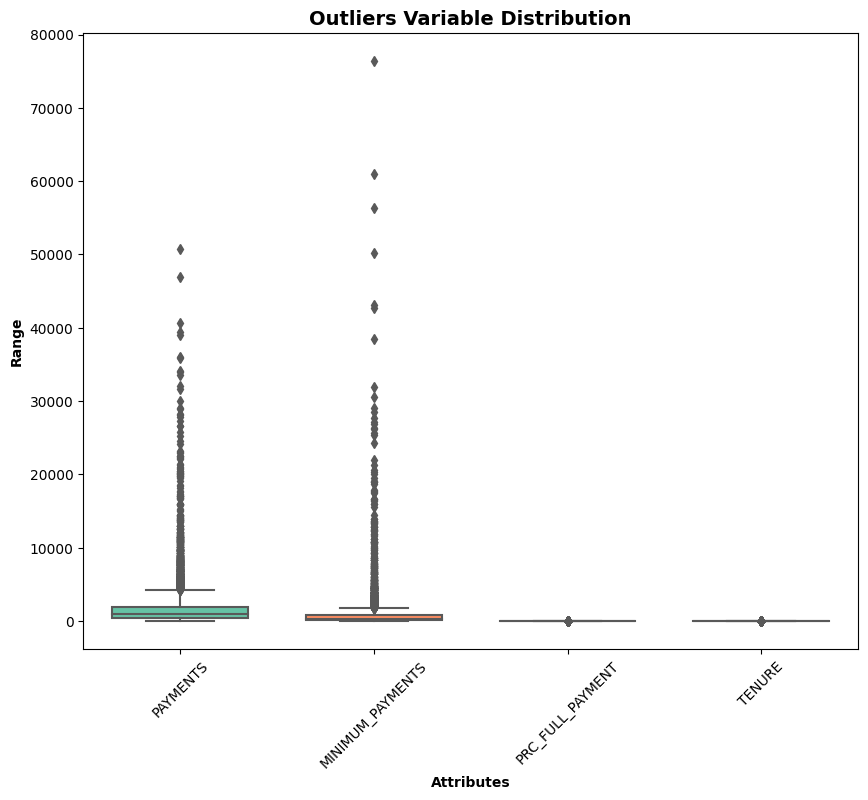

In [ ]:
num_attributes_3 = num_attributes[len(num_attributes)-4:]
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = df[num_attributes_3], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')
plt.xticks(rotation=45)

**Removing the outliers**

In [ ]:
# Removing (statistical) outliers for BALANCE
Q1 = df.BALANCE.quantile(0.05)
Q3 = df.BALANCE.quantile(0.95)
IQR = Q3 - Q1
df = df[(df.BALANCE >= Q1 - 1.5*IQR) & (df.BALANCE <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for PURCHASES
Q1 = df.PURCHASES.quantile(0.05)
Q3 = df.PURCHASES.quantile(0.95)
IQR = Q3 - Q1
df = df[(df.PURCHASES >= Q1 - 1.5*IQR) & (df.PURCHASES <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for ONEOFF_PURCHASES
Q1 = df.ONEOFF_PURCHASES.quantile(0.05)
Q3 = df.ONEOFF_PURCHASES.quantile(0.95)
IQR = Q3 - Q1
df = df[(df.ONEOFF_PURCHASES >= Q1 - 1.5*IQR) & (df.ONEOFF_PURCHASES <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for INSTALLMENTS_PURCHASES'
Q1 = df.INSTALLMENTS_PURCHASES.quantile(0.05)
Q3 = df.INSTALLMENTS_PURCHASES.quantile(0.95)
IQR = Q3 - Q1
df = df[(df.INSTALLMENTS_PURCHASES >= Q1 - 1.5*IQR) & (df.INSTALLMENTS_PURCHASES <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for CASH_ADVANCE
Q1 = df.CASH_ADVANCE.quantile(0.05)
Q3 = df.CASH_ADVANCE.quantile(0.95)
IQR = Q3 - Q1
df = df[(df.CASH_ADVANCE >= Q1 - 1.5*IQR) & (df.CASH_ADVANCE <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for CREDIT_LIMIT
Q1 = df.CREDIT_LIMIT.quantile(0.05)
Q3 = df.CREDIT_LIMIT.quantile(0.95)
IQR = Q3 - Q1
df = df[(df.CREDIT_LIMIT >= Q1 - 1.5*IQR) & (df.CREDIT_LIMIT <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for PURCHASES
Q1 = df.PAYMENTS.quantile(0.05)
Q3 = df.PAYMENTS.quantile(0.95)
IQR = Q3 - Q1
df = df[(df.PAYMENTS >= Q1 - 1.5*IQR) & (df.PAYMENTS <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for PURCHASES
Q1 = df.MINIMUM_PAYMENTS.quantile(0.05)
Q3 = df.MINIMUM_PAYMENTS.quantile(0.95)
IQR = Q3 - Q1
df = df[(df.MINIMUM_PAYMENTS >= Q1 - 1.5*IQR) & (df.MINIMUM_PAYMENTS <= Q3 + 1.5*IQR)]


**Rescaling the features using Standardisation Scaling**

1. Equality Among Features: 🌐 Clustering algorithms, such as K-Means, operate based on distances between data points. Standard scaling ensures that all features contribute equally to this distance computation, preventing dominance by features with larger scales.

2. Consistency in Influence: 🤹‍♂️ Features with disparate scales might influence the clustering process unevenly. Standard scaling puts them on a level playing field, promoting fair influence and preventing one feature from overshadowing others.

3. Enhancing Convergence: 🚀 Standardizing feature scales accelerates the convergence of clustering algorithms. Faster convergence is particularly crucial for large datasets and complex clustering structures.

How to Standard Scale?

Using Standard Scaling (Z-score normalization) involves the following steps:

Calculate Mean and Standard Deviation: Compute the mean (
μ
μ) and standard deviation (
σ
σ) for each feature in the dataset.
Standardize Features: For each feature, subtract the mean and divide by the standard deviation:
(
X
−
μ
)
σ
σ
(X−μ)
​


In [ ]:
# Rescaling the attributes

df_scaled = df[num_attributes]

# Instantiate
scaler = StandardScaler()

# fit_transform
df_scaled = scaler.fit_transform(df_scaled)
df_scaled.shape
df_scaled=pd.DataFrame(df_scaled)
df_scaled.columns=df[num_attributes].columns

In [ ]:
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.756102,-0.356504,-0.616302,-0.534021,-0.438214,-0.534894,-0.807260,-0.677084,-0.706090,-0.684639,-0.495840,-0.563236,-0.973301,-0.746423,-0.599739,-0.533994,0.3596
1,0.894173,0.077898,-0.698047,-0.534021,-0.600612,3.321329,-1.224305,-0.677084,-0.916909,0.577341,0.132572,-0.662080,0.776392,1.559389,0.544023,0.221381,0.3596
2,0.524966,0.512301,-0.035544,0.359536,-0.600612,-0.534894,1.277961,2.745328,-0.916909,-0.684639,-0.495840,-0.069013,0.922200,-0.498027,-0.001668,-0.533994,0.3596
3,-0.350621,0.512301,-0.684337,-0.515530,-0.600612,-0.534894,-1.015783,-0.391884,-0.916909,-0.684639,-0.495840,-0.612658,-0.914978,-0.464769,-0.470651,-0.533994,0.3596
4,0.167243,0.512301,0.444395,-0.534021,1.669008,-0.534894,0.443873,-0.677084,0.558829,-0.684639,-0.495840,-0.266702,-0.740008,-0.038197,2.180777,-0.533994,0.3596


In [ ]:
df_scaled.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

**K Means Clustering**

![](https://miro.medium.com/v2/resize:fit:1200/1*rw8IUza1dbffBhiA4i0GNQ.png)

In [ ]:
# k-means with some arbitrary k

kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit(df_scaled)

KMeans(max_iter=50, n_clusters=4)

Building the Clustering Model

In [ ]:
kmeans.labels_

array([2, 0, 1, ..., 1, 2, 2], dtype=int32)

The Elbow Method is one of the most popular methods to determine this optimal value of k.

Elbow Method: Finding the Optimal Number of Clusters 🕵️‍♂️📉

What is the Elbow Method?

The Elbow Method is a technique used to identify the optimal number of clusters in a dataset for clustering algorithms like K-Means. It involves running the algorithm with different values of k (number of clusters) and plotting the cost or distortion (inertia) against k. The "elbow" of the curve represents a point where adding more clusters does not significantly reduce the cost, indicating an optimal number of clusters.

How Does the Elbow Method Work?

K-Means Clustering: 🤖 The K-Means algorithm is run with different values of k.
Cost Calculation: 💰 The cost (inertia) of the clustering solution is computed for each k. Inertia measures how far points in a cluster are from the centroid.
Elbow Plotting: 📈 The costs are plotted against the corresponding values of k.
Elbow Identification: 👀 The "elbow" of the plot, where the cost starts to flatten out, indicates the optimal number of clusters.

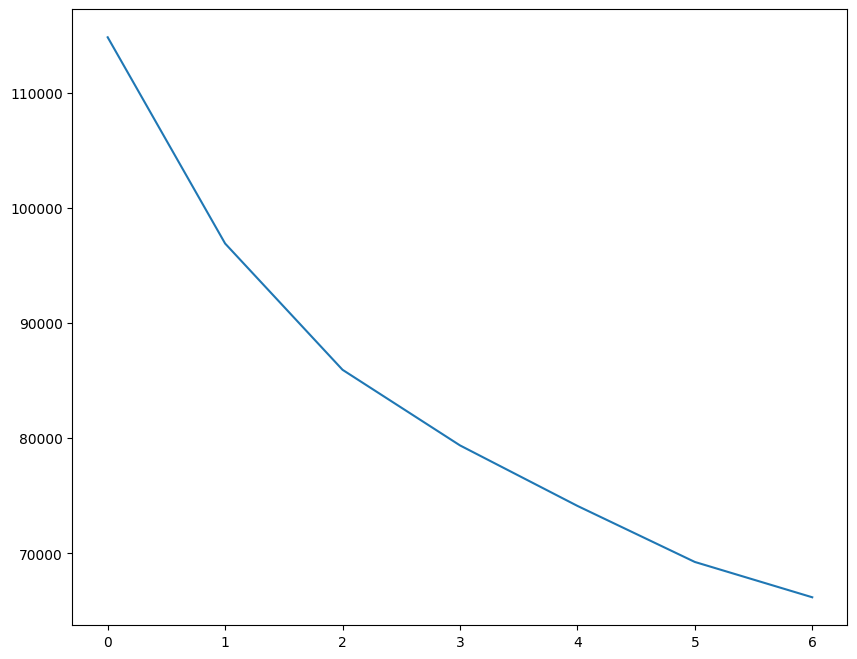

In [ ]:
# Elbow-curve/SSD

ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(df_scaled)

    ssd.append(kmeans.inertia_)

# plot the SSDs for each n_clusters
plt.plot(ssd)

What is Silhouette Analysis?

Silhouette Analysis is a technique used to evaluate the goodness of a clustering algorithm's output. It quantifies how well-defined and separated the clusters are within a dataset.

How Does Silhouette Analysis Work?

Silhouette Coefficient Calculation: 📈 For each data point, the silhouette coefficient is computed. This coefficient measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation).
Range of Silhouette Coefficient: 📏 The silhouette coefficient ranges from -1 to 1. A high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
Interpretation:
Near +1: Indicates that the object is well inside its own cluster and far from neighboring clusters.
Around 0: Suggests overlapping clusters.
Near -1: Implies that the object may be assigned to the wrong cluster.

In [ ]:
# Silhouette analysis

range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:

    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(df_scaled)

    cluster_labels = kmeans.labels_

    # silhouette score
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))


For n_clusters=2, the silhouette score is 0.20555147749397207
For n_clusters=3, the silhouette score is 0.24227969576374936
For n_clusters=4, the silhouette score is 0.18627922821758397
For n_clusters=5, the silhouette score is 0.18955658180147697
For n_clusters=6, the silhouette score is 0.20119556478736747
For n_clusters=7, the silhouette score is 0.21140351630332516
For n_clusters=8, the silhouette score is 0.21369385379291447


In [ ]:
# Final model with k=3
kmeans = KMeans(n_clusters=3, max_iter=50)
kmeans.fit(df_scaled)

KMeans(max_iter=50, n_clusters=3)

In [ ]:
 kmeans.labels_

array([0, 2, 0, ..., 0, 0, 0], dtype=int32)

In [ ]:
# assign the label
df['Cluster_Id'] = kmeans.labels_
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster_Id
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12,0
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12,0
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12,0


We will visualize Cluster Id with different features to validate the results

<Axes: xlabel='Cluster_Id', ylabel='CASH_ADVANCE'>

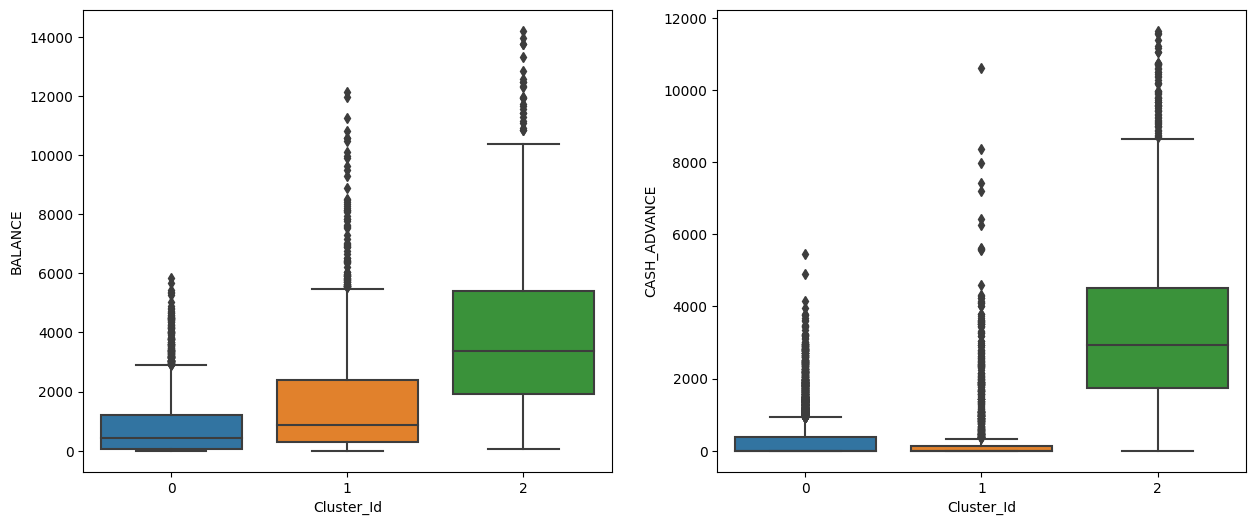

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(x='Cluster_Id', y='BALANCE', data=df)

plt.subplot(1,2,2)
sns.boxplot(x='Cluster_Id', y='CASH_ADVANCE', data=df)

<Axes: xlabel='Cluster_Id', ylabel='PURCHASES'>

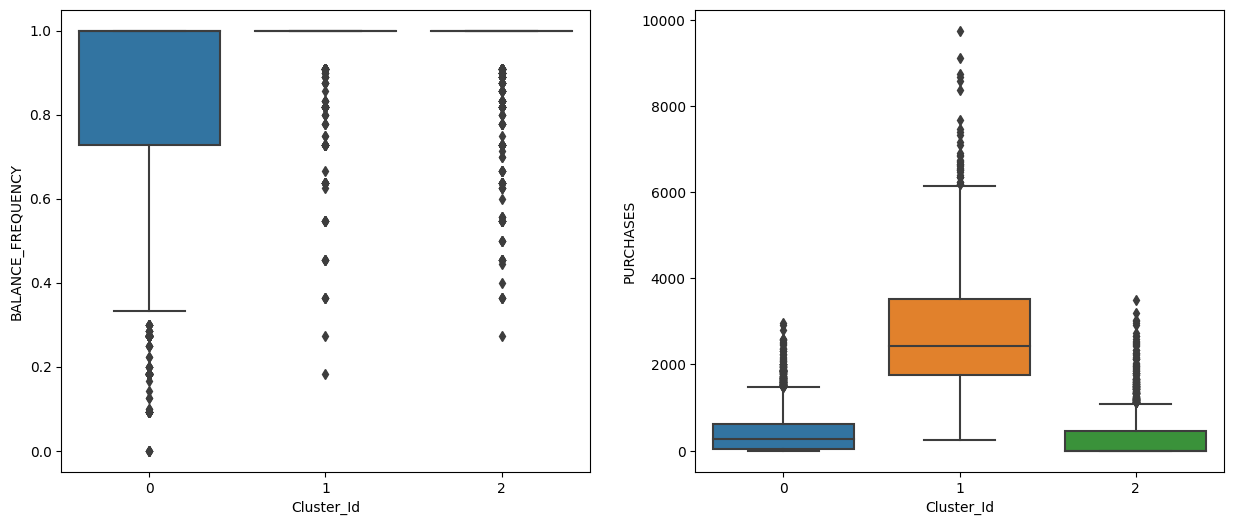

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(x='Cluster_Id', y='BALANCE_FREQUENCY', data=df)

plt.subplot(1,2,2)
sns.boxplot(x='Cluster_Id', y='PURCHASES', data=df)

<Axes: xlabel='Cluster_Id', ylabel='MINIMUM_PAYMENTS'>

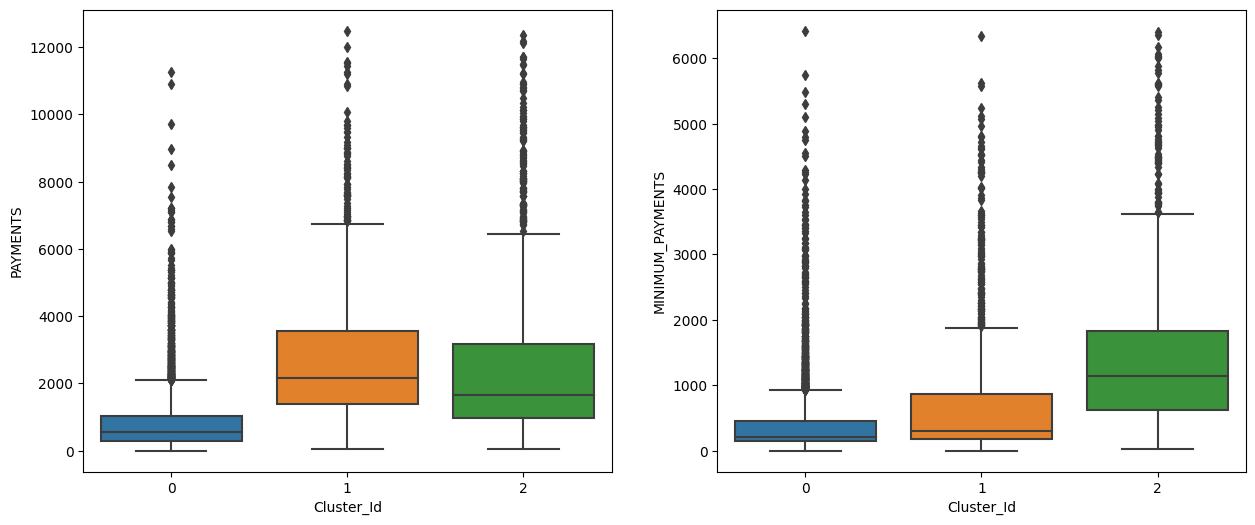

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(x='Cluster_Id', y='PAYMENTS', data=df)

plt.subplot(1,2,2)
sns.boxplot(x='Cluster_Id', y='MINIMUM_PAYMENTS', data=df)

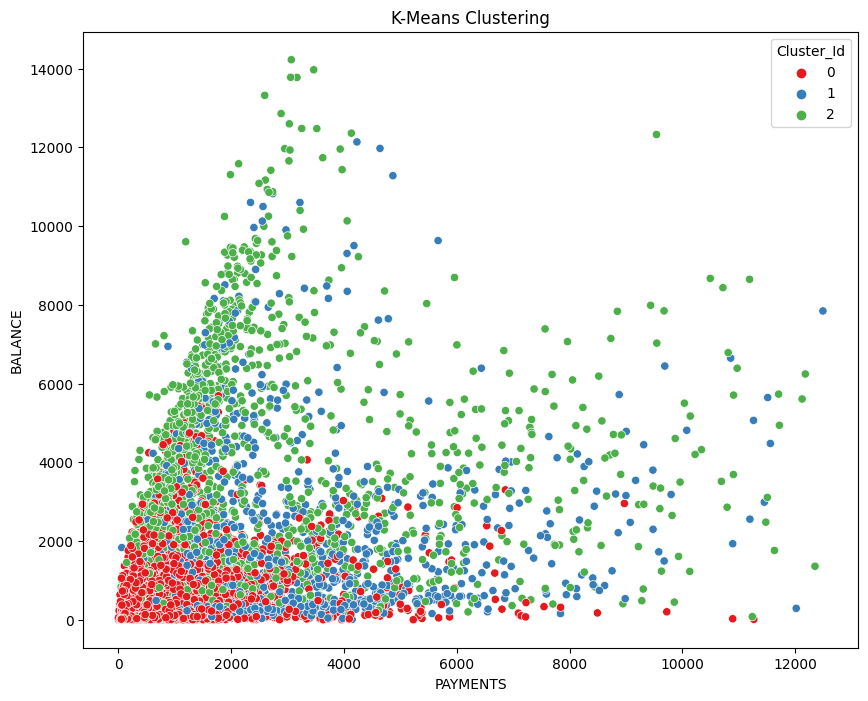

In [ ]:
sns.scatterplot(data=df, x='PAYMENTS', y='BALANCE', hue='Cluster_Id', palette='Set1')
plt.title('K-Means Clustering')
plt.show()

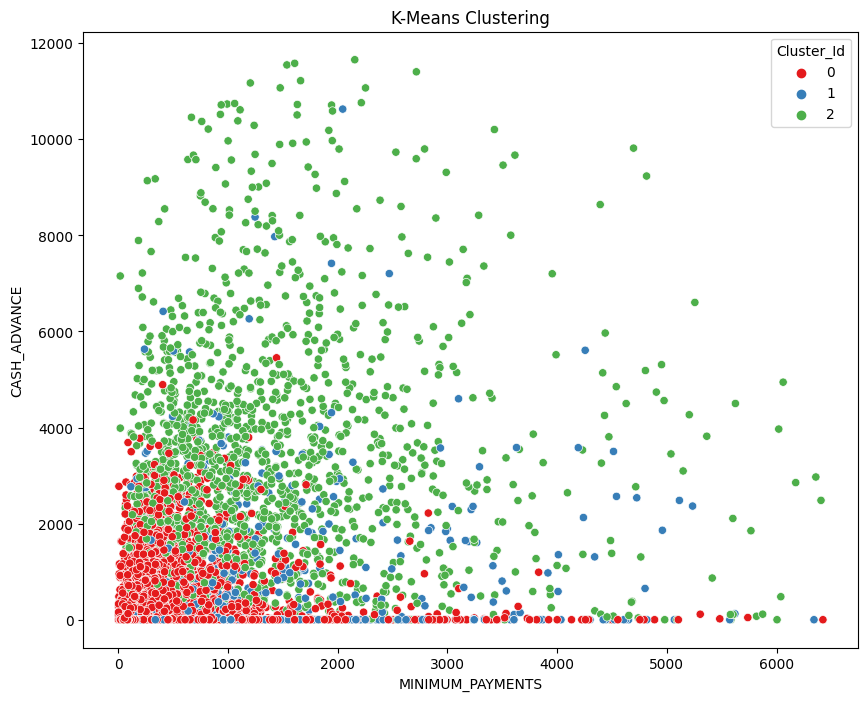

In [ ]:
sns.scatterplot(data=df, x='MINIMUM_PAYMENTS', y='CASH_ADVANCE', hue='Cluster_Id', palette='Set1')
plt.title('K-Means Clustering')
plt.show()

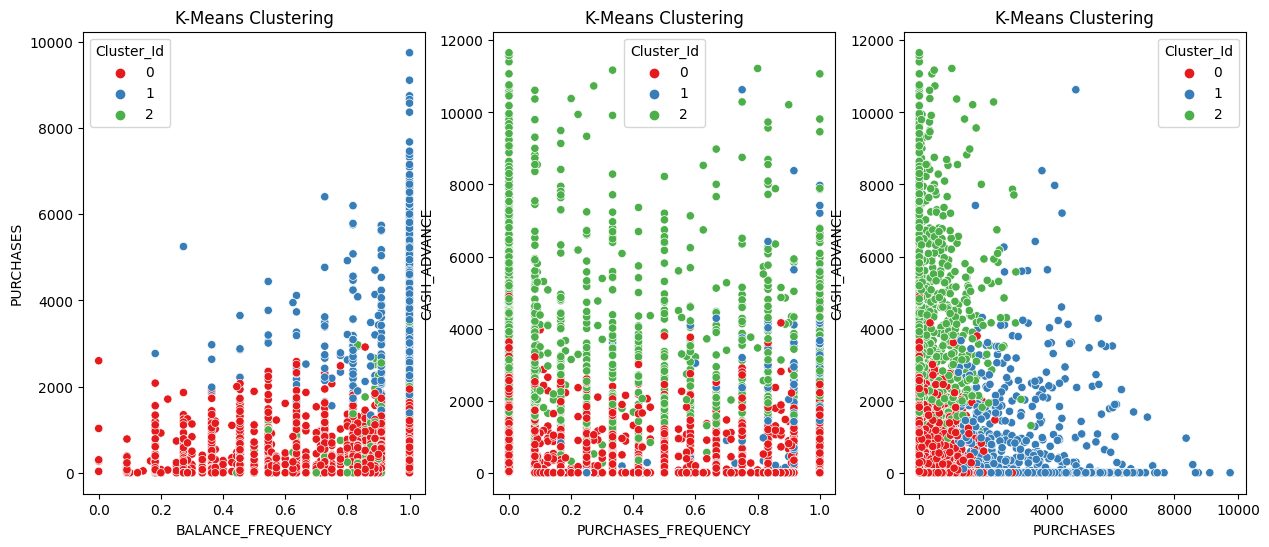

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
sns.scatterplot(data=df, x='BALANCE_FREQUENCY', y='PURCHASES', hue='Cluster_Id', palette='Set1')
plt.title('K-Means Clustering')

plt.subplot(1,3,2)
sns.scatterplot(data=df, x='PURCHASES_FREQUENCY', y='CASH_ADVANCE', hue='Cluster_Id', palette='Set1')
plt.title('K-Means Clustering')

plt.subplot(1,3,3)
sns.scatterplot(data=df, x='PURCHASES', y='CASH_ADVANCE', hue='Cluster_Id', palette='Set1')
plt.title('K-Means Clustering')

plt.show()

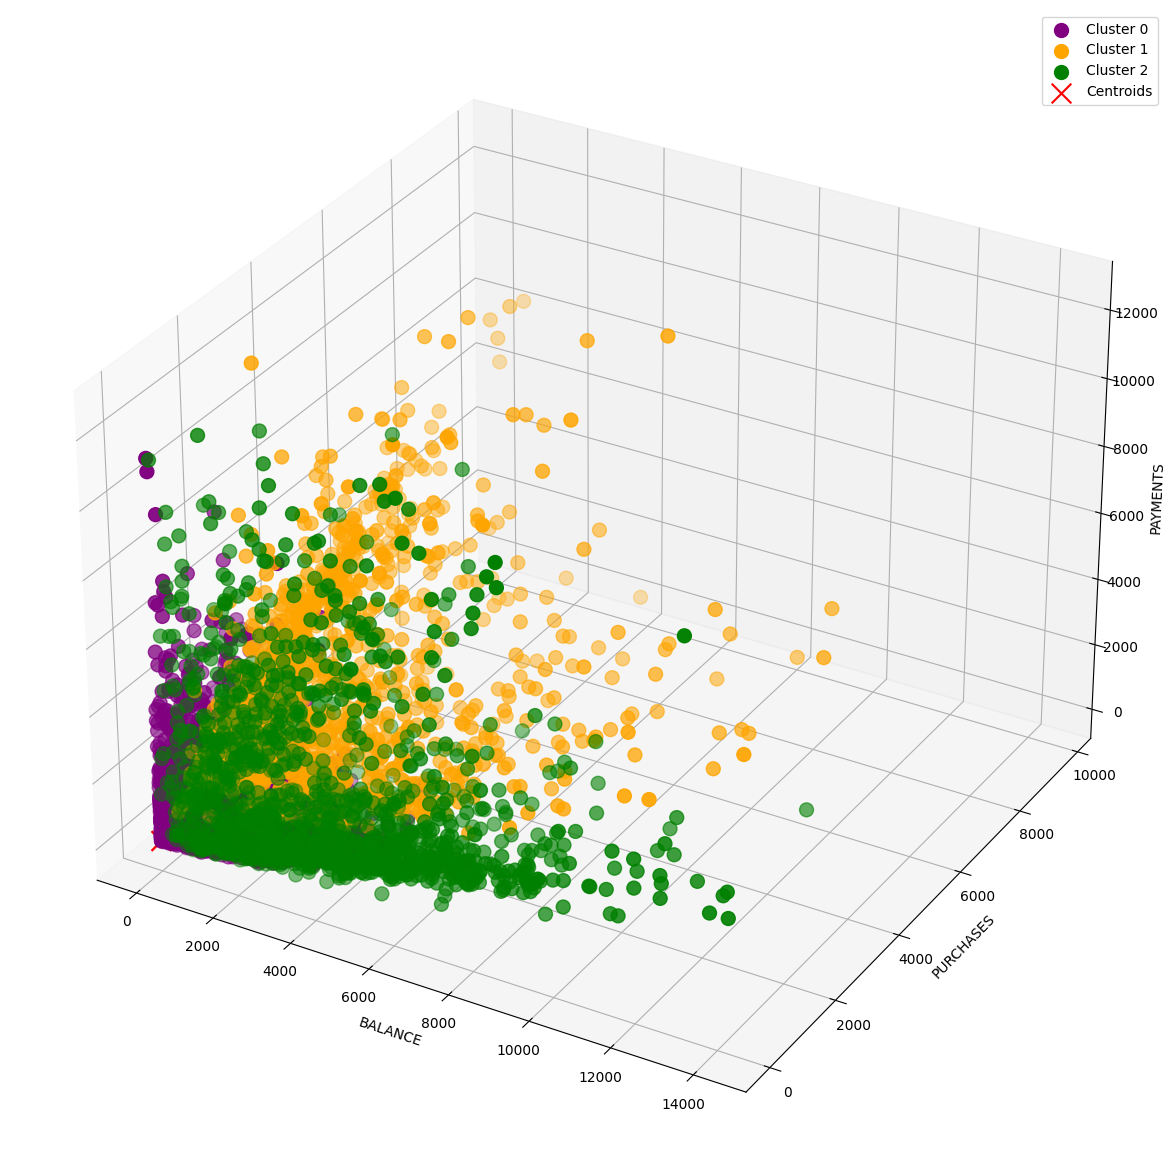

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# Scatter points for each cluster, adjust colors and labels
ax.scatter(df[df['Cluster_Id'] == 0]['BALANCE'], df[df['Cluster_Id'] == 0]['PURCHASES'], df[df['Cluster_Id'] == 0]['PAYMENTS'], s=100, c='purple', label='Cluster 0')
ax.scatter(df[df['Cluster_Id'] == 1]['BALANCE'], df[df['Cluster_Id'] == 1]['PURCHASES'], df[df['Cluster_Id'] == 1]['PAYMENTS'], s=100, c='orange', label='Cluster 1')
ax.scatter(df[df['Cluster_Id'] == 2]['BALANCE'], df[df['Cluster_Id'] == 2]['PURCHASES'], df[df['Cluster_Id'] == 2]['PAYMENTS'], s=100, c='green', label='Cluster 2')

# Plot centroids of the clusters
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=200, c='red', marker='x', label='Centroids')

# Add labels and legend
ax.set_xlabel('BALANCE')
ax.set_ylabel('PURCHASES')
ax.set_zlabel('PAYMENTS')
plt.legend(loc='upper right')

# Show the 3D scatterplot
plt.show()

**Hierarchical Clustering**

![](https://miro.medium.com/v2/resize:fit:740/1*VvOVxdBb74IOxxF2RmthCQ.png)

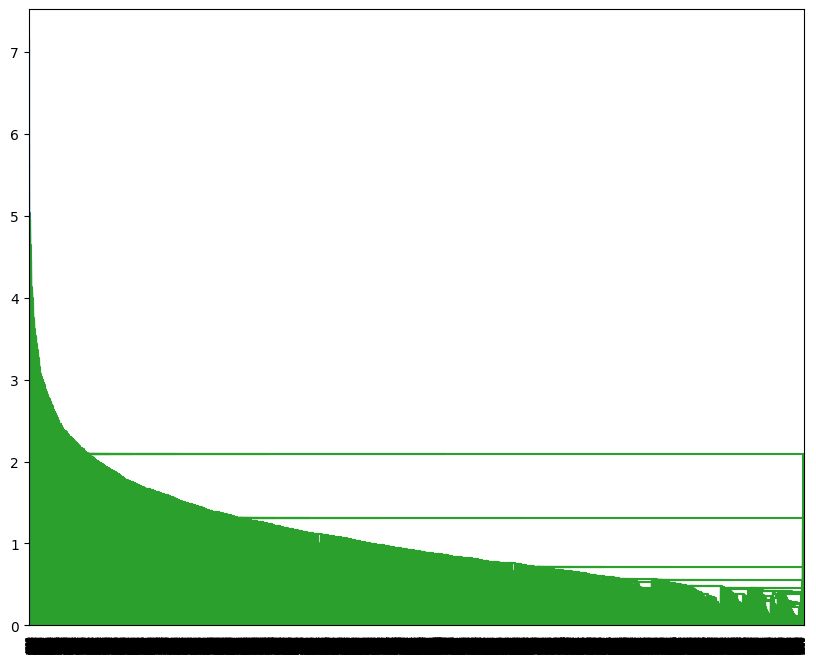

In [ ]:
import sys
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Increase the recursion limit
sys.setrecursionlimit(10000)  # You can adjust the limit as needed
# Single linkage:
mergings = linkage(df_scaled, method="single", metric='euclidean')
dendrogram(mergings)
plt.show()

Processing might take some time.

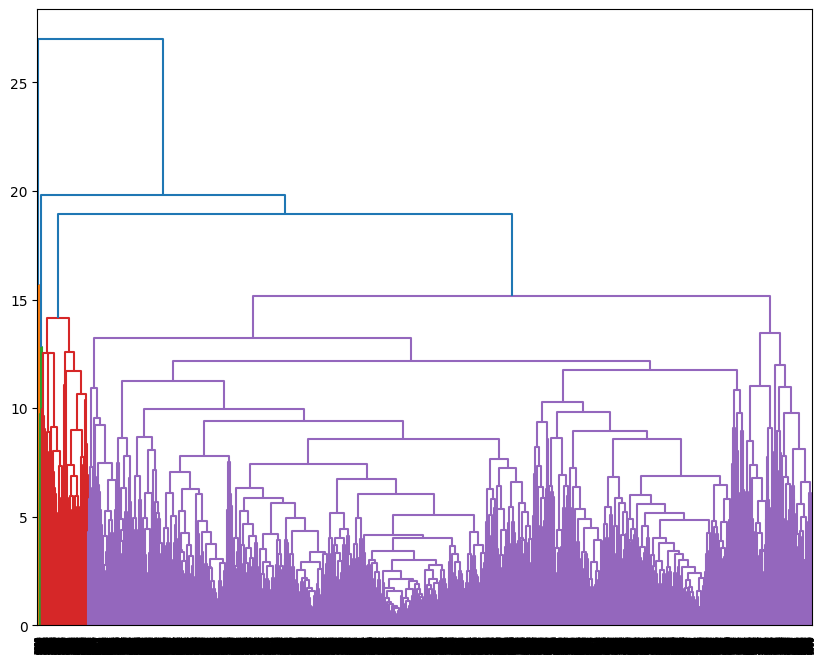

In [ ]:
# Complete linkage

mergings_c = linkage(df_scaled, method="complete", metric='euclidean')
dendrogram(mergings_c)
plt.show()

In [ ]:
# since we had hot optimal 3 clusters we will cute dendogram there
cluster_labels = cut_tree(mergings_c, n_clusters=3).reshape(-1, )
cluster_labels

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# Assign cluster labels for Hierarchical Clustering
df_1=df.copy()
df_1['Cluster_Labels'] = cluster_labels
df_1.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster_Id,Cluster_Labels
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12,0,0
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12,0,0
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12,0,0
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12,0,0


<Axes: xlabel='Cluster_Id', ylabel='MINIMUM_PAYMENTS'>

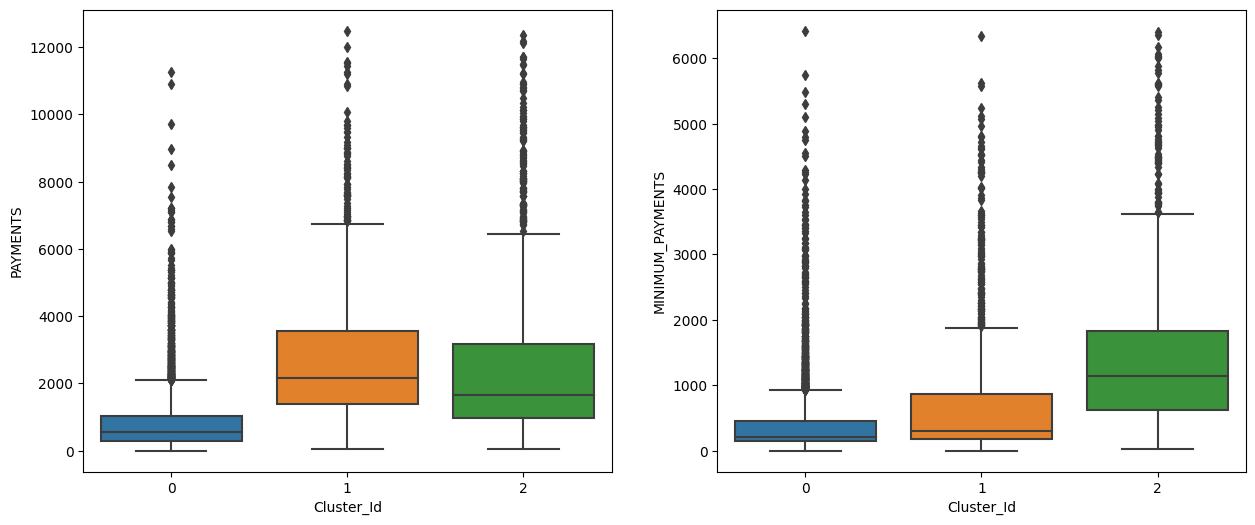

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(x='Cluster_Id', y='PAYMENTS', data=df_1)

plt.subplot(1,2,2)
sns.boxplot(x='Cluster_Id', y='MINIMUM_PAYMENTS', data=df_1)

<Axes: xlabel='Cluster_Id', ylabel='PURCHASES'>

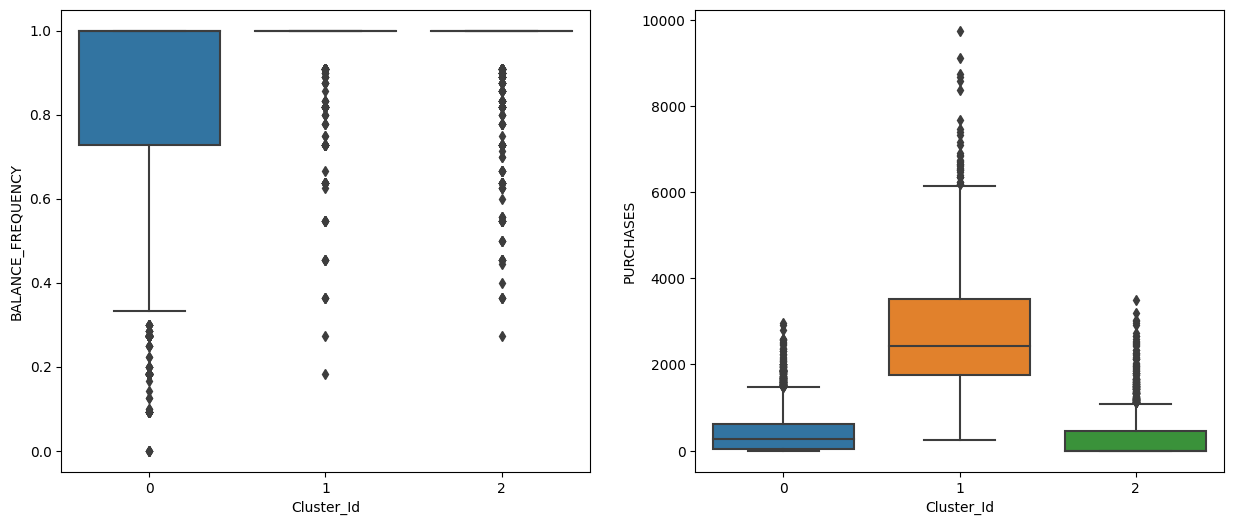

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(x='Cluster_Id', y='BALANCE_FREQUENCY', data=df_1)

plt.subplot(1,2,2)
sns.boxplot(x='Cluster_Id', y='PURCHASES', data=df_1)

<Axes: xlabel='Cluster_Id', ylabel='CASH_ADVANCE'>

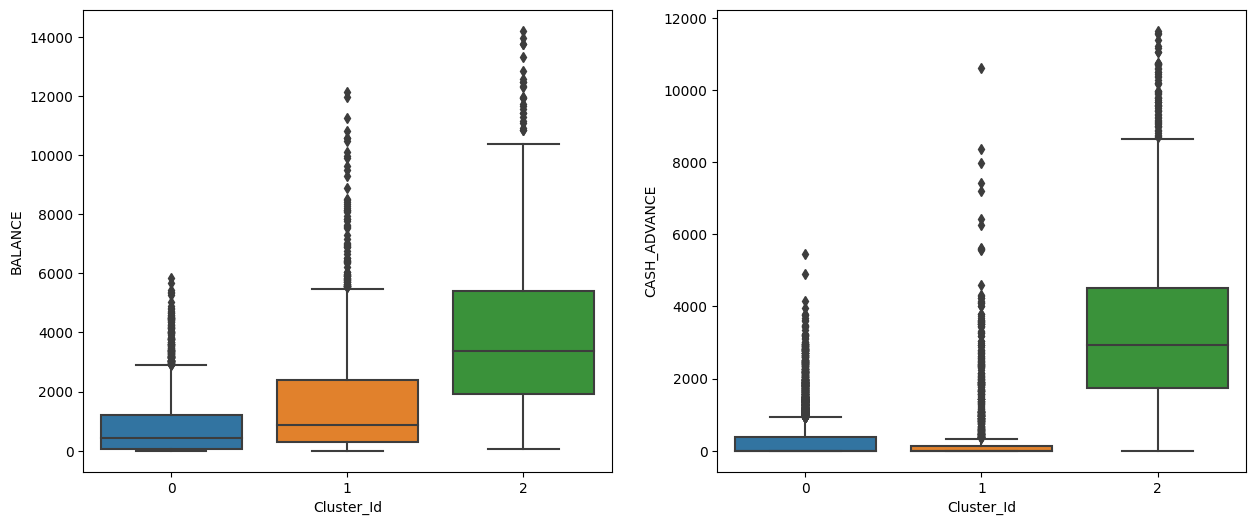

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
sns.boxplot(x='Cluster_Id', y='BALANCE', data=df_1)

plt.subplot(1,2,2)
sns.boxplot(x='Cluster_Id', y='CASH_ADVANCE', data=df_1)

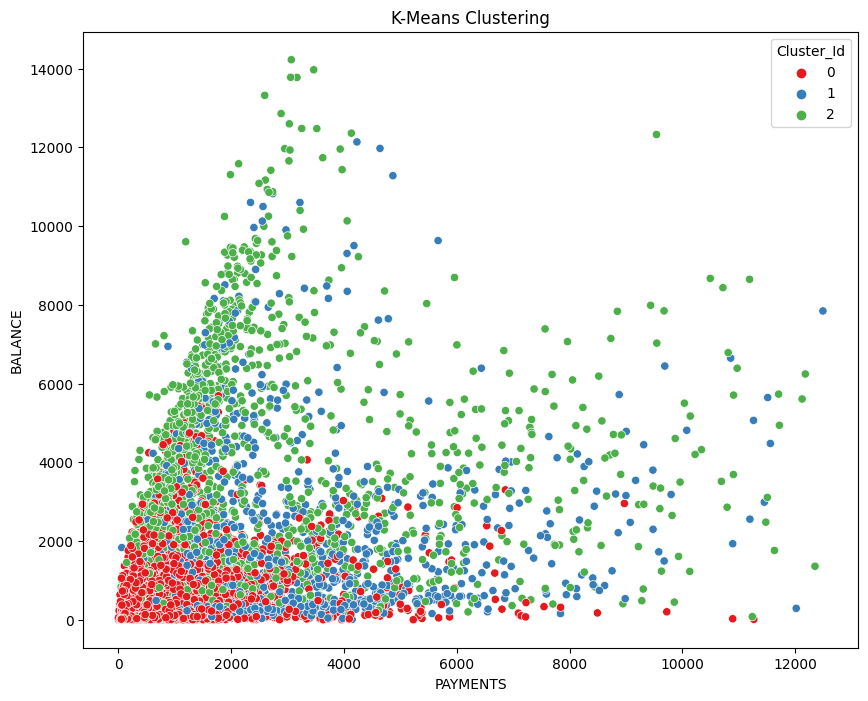

In [ ]:
sns.scatterplot(data=df_1, x='PAYMENTS', y='BALANCE', hue='Cluster_Id', palette='Set1')
plt.title('K-Means Clustering')
plt.show()

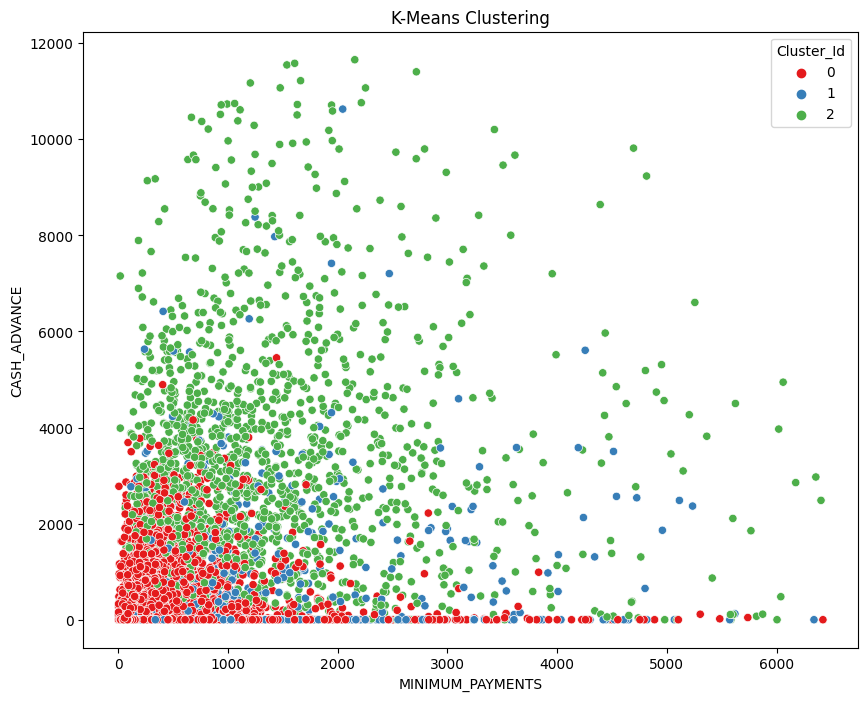

In [ ]:
sns.scatterplot(data=df_1, x='MINIMUM_PAYMENTS', y='CASH_ADVANCE', hue='Cluster_Id', palette='Set1')
plt.title('K-Means Clustering')
plt.show()